In [21]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '/content/spectra_log.csv'
df = pd.read_csv(file_path)

print(f"Successfully loaded data from {file_path}.")
display(df.head())



Successfully loaded data from /content/spectra_log.csv.


,Timestamp,IntegrationTime_us,LED_State,Comment,Max_ADC,P0,P1,P2,P3,P4,...,P278,P279,P280,P281,P282,P283,P284,P285,P286,P287
0,2026-09-23 09:37:56.816,195152,ON,Turmeric,2559,377,344,339,336,346,...,338,346,336,343,340,336,347,346,337,341
1,2026-09-23 09:38:26.016,161374,ON,Turmeric,2536,379,338,336,334,339,...,336,341,334,336,336,337,345,336,367,339
2,2026-09-23 09:38:56.179,157266,ON,Turmeric,2532,381,339,335,337,334,...,334,336,327,327,338,304,341,334,338,336
3,2026-09-23 09:39:26.246,152234,ON,Turmeric,2593,375,338,335,336,336,...,339,336,336,336,342,336,347,336,343,347
4,2026-09-23 09:39:56.261,143530,ON,Turmeric,2454,375,338,338,332,336,...,337,339,334,336,339,340,347,338,346,338


In [22]:
# Normalize spectral columns by IntegrationTime_us
df_corrected = df.copy()
df_corrected[spectral_columns] = df_corrected[spectral_columns].div(df_corrected['IntegrationTime_us'], axis=0)

print("Spectral data normalized by IntegrationTime_us. Head of corrected data:")
display(df_corrected.head())

Spectral data normalized by IntegrationTime_us. Head of corrected data:


,Timestamp,IntegrationTime_us,LED_State,Comment,Max_ADC,P0,P1,P2,P3,P4,...,P278,P279,P280,P281,P282,P283,P284,P285,P286,P287
0,2026-09-23 09:37:56.816,195152,ON,Turmeric,2559,0.001932,0.001763,0.001737,0.001722,0.001773,...,0.001732,0.001773,0.001722,0.001758,0.001742,0.001722,0.001778,0.001773,0.001727,0.001747
1,2026-09-23 09:38:26.016,161374,ON,Turmeric,2536,0.002349,0.002095,0.002082,0.002070,0.002101,...,0.002082,0.002113,0.002070,0.002082,0.002082,0.002088,0.002138,0.002082,0.002274,0.002101
2,2026-09-23 09:38:56.179,157266,ON,Turmeric,2532,0.002423,0.002156,0.002130,0.002143,0.002124,...,0.002124,0.002137,0.002079,0.002079,0.002149,0.001933,0.002168,0.002124,0.002149,0.002137
3,2026-09-23 09:39:26.246,152234,ON,Turmeric,2593,0.002463,0.002220,0.002201,0.002207,0.002207,...,0.002227,0.002207,0.002207,0.002207,0.002247,0.002207,0.002279,0.002207,0.002253,0.002279
4,2026-09-23 09:39:56.261,143530,ON,Turmeric,2454,0.002613,0.002355,0.002355,0.002313,0.002341,...,0.002348,0.002362,0.002327,0.002341,0.002362,0.002369,0.002418,0.002355,0.002411,0.002355


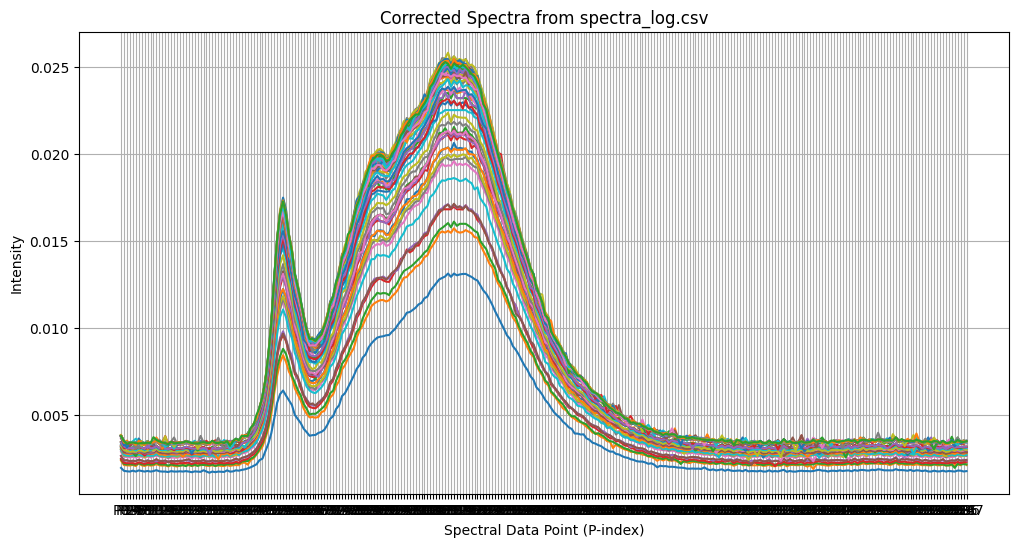

In [25]:
spectral_columns = [col for col in df.columns if col.startswith('P') and col[1:].isdigit()]

plt.figure(figsize=(12, 6))
for index, row in df_corrected.iterrows():
    plt.plot(spectral_columns, row[spectral_columns], label=f'Spectrum {index}')

plt.xlabel('Spectral Data Point (P-index)')
plt.ylabel('Intensity')
plt.title('Corrected Spectra from spectra_log.csv')
# To avoid cluttering with too many labels, only show legend if there are few spectra
if len(df_corrected) <= 10:
    plt.legend()
plt.grid(True)
plt.show()

In [26]:
import re
import numpy as np

# 1. Calibration coefficients for Serial 21A02875
A0 = 3.086965198E+02
B1 = 2.718912698E+00
B2 = -1.434471882E-03
B3 = -5.759067943E-06
B4 = 3.250344320E-09
B5 = 1.237572658E-11

def pixel_to_wavelength(pix_rel):
    return (A0 +
            B1 * pix_rel +
            B2 * (pix_rel ** 2) +
            B3 * (pix_rel ** 3) +
            B4 * (pix_rel ** 4) +
            B5 * (pix_rel ** 5))

In [27]:
active_cols = spectral_columns
# 4. Compute wavelengths using the relative active index (P0 -> index 0)
active_pixel_indices = np.array([int(col[1:]) for col in active_cols], dtype=float)
wavelengths = pixel_to_wavelength(active_pixel_indices)

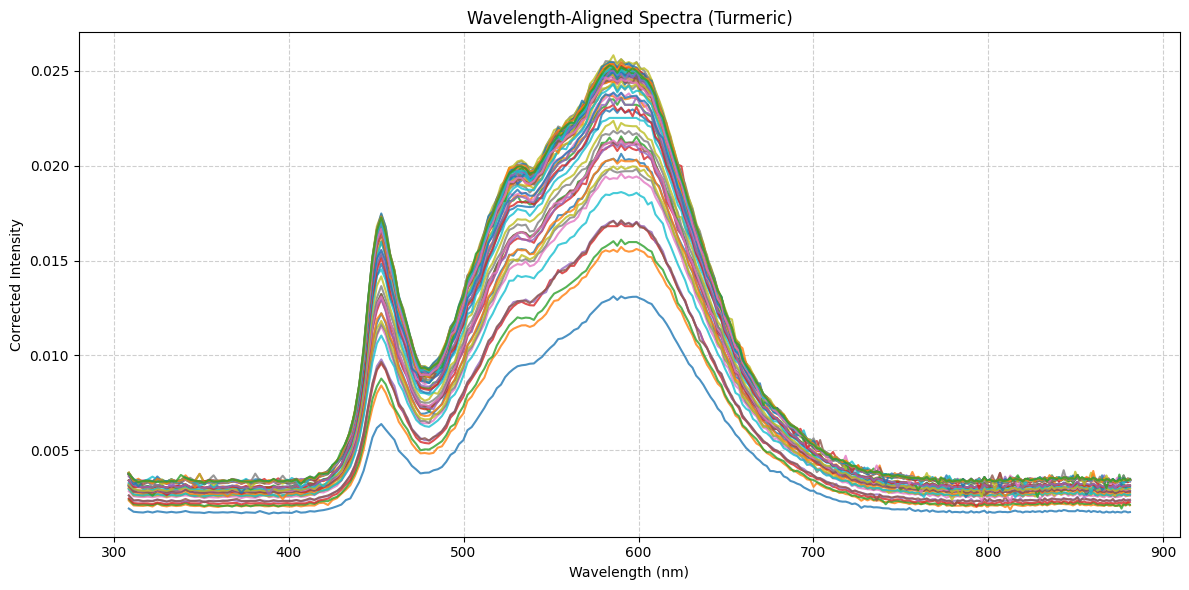

In [28]:
plt.figure(figsize=(12, 6))

# df_corrected is now expected to be normalized from a previous cell
for index, row in df_corrected.iterrows():
    plt.plot(wavelengths, row[active_cols], alpha=0.8, label=f'Spectrum {index}' if len(df) <= 10 else "")

plt.xlabel('Wavelength (nm)')
plt.ylabel('Corrected Intensity')
plt.title('Wavelength-Aligned Spectra (Turmeric)')

# Only show legend if there are 10 or fewer spectra to avoid clutter
if len(df) <= 10:
    plt.legend(loc='upper right')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

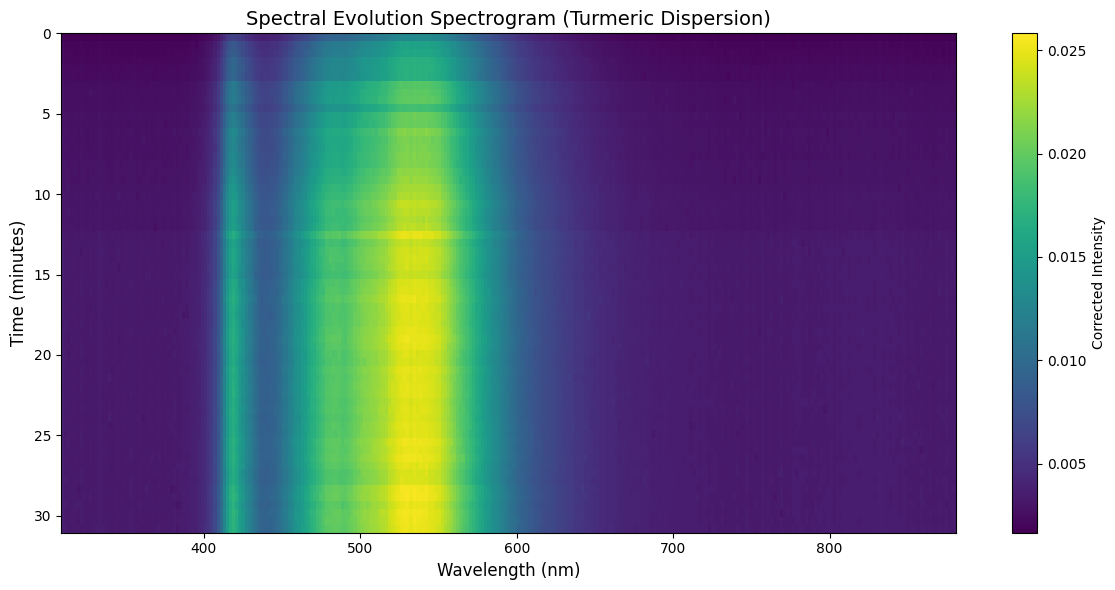

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Convert Timestamp to datetime objects
df_corrected['Timestamp'] = pd.to_datetime(df_corrected['Timestamp'])

# Calculate time difference from the first timestamp in minutes
time_minutes = (df_corrected['Timestamp'] - df_corrected['Timestamp'].iloc[0]).dt.total_seconds() / 60.0
intensity_matrix = df_corrected[active_cols].values

plt.figure(figsize=(12, 6))

# Plot heatmap with wavelengths on X-axis and time on Y-axis
im = plt.imshow(
    intensity_matrix,
    aspect='auto',
    extent=[wavelengths[0], wavelengths[-1], time_minutes.iloc[-1], time_minutes.iloc[0]], # Use iloc for min/max
    cmap='viridis'
)

# Add colorbar and clearly label axes
cbar = plt.colorbar(im)
cbar.set_label('Corrected Intensity')

plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Time (minutes)', fontsize=12)
plt.title('Spectral Evolution Spectrogram (Turmeric Dispersion)', fontsize=14)

plt.grid(False) # Heatmaps look cleaner without a grid overlay
plt.tight_layout()
plt.show()

=== Automated Dispersion Stability Report ===
Sedimentation Rate: 2.280% change per minute
 -> STATUS: Suspension is stable against heavy sedimentation.
Agglomeration Slope: -0.00606 units/min
 -> ALERT: Spectral slope shifting, indicating possible particle growth/flocculation.


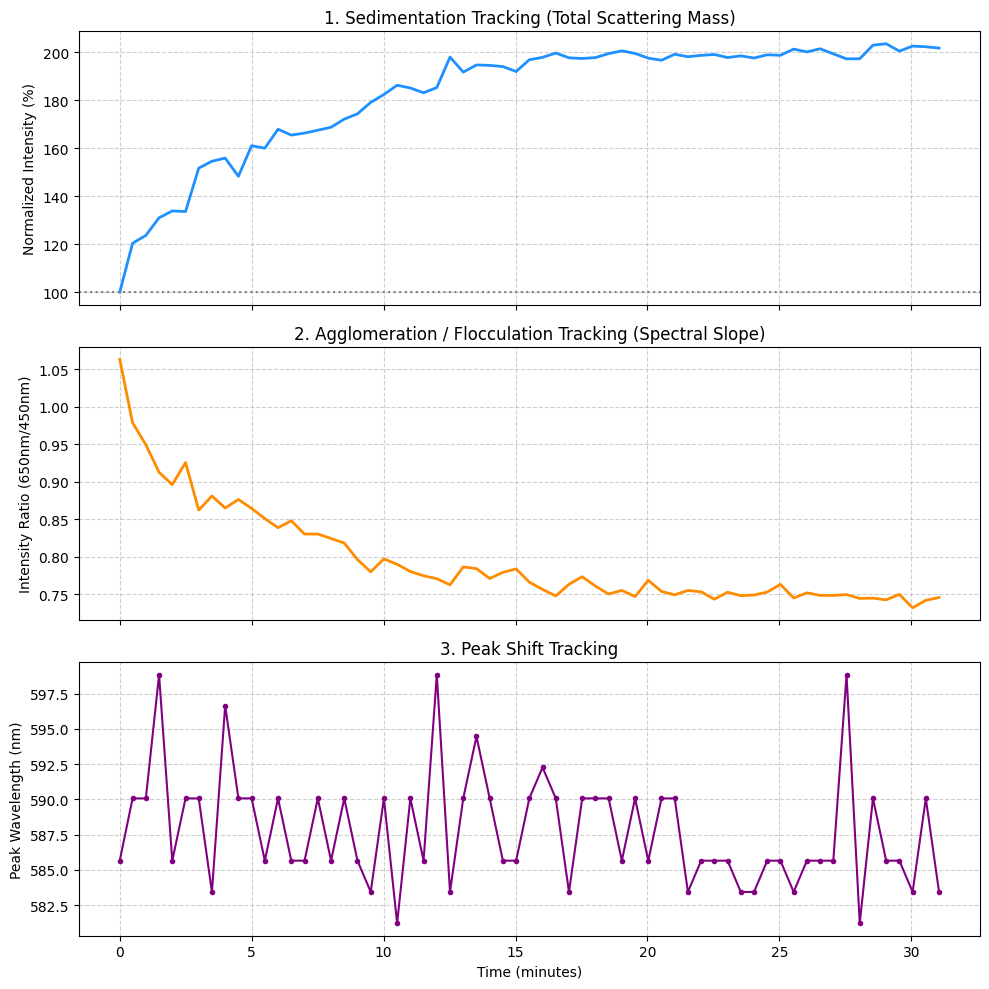

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

def analyze_dispersion_stability(df_corrected, active_cols, wavelengths):
    """
    Analyzes a time-series spectral log for sedimentation, agglomeration, and flocculation.
    """
    # 1. Setup Time Axis (in minutes)
    # Ensure 'Timestamp' is datetime type
    df_corrected['Timestamp'] = pd.to_datetime(df_corrected['Timestamp'])
    time_minutes = (df_corrected['Timestamp'] - df_corrected['Timestamp'].iloc[0]).dt.total_seconds() / 60.0

    intensity_matrix = df_corrected[active_cols].values

    # 2. Metric A: Sedimentation (Total Integrated Intensity)
    total_intensity = df_corrected[active_cols].sum(axis=1)
    sedimentation_norm = (total_intensity / total_intensity.iloc[0]) * 100 # Normalized to % of initial

    # 3. Metric B: Agglomeration/Particle Growth (Spectral Slope / Ratio)
    idx_450 = np.argmin(np.abs(wavelengths - 450))
    idx_650 = np.argmin(np.abs(wavelengths - 650))

    col_450 = active_cols[idx_450]
    col_650 = active_cols[idx_650]
    spectral_ratio = df_corrected[col_650] / df_corrected[col_450]

    # 4. Metric C: Peak Wavelength Shift
    max_idx_cols = df_corrected[active_cols].idxmax(axis=1)
    peak_wavelengths = [wavelengths[active_cols.index(col)] for col in max_idx_cols]

    # 5. Linear Trends (Rates of Change)
    sed_slope, _, _, _, _ = linregress(time_minutes, sedimentation_norm)
    ratio_slope, _, _, _, _ = linregress(time_minutes, spectral_ratio)

    print("=== Automated Dispersion Stability Report ===")
    print(f"Sedimentation Rate: {sed_slope:.3f}% change per minute")
    if sed_slope < -0.5:
        print(" -> ALERT: Significant sedimentation detected (particles dropping out).")
    else:
        print(" -> STATUS: Suspension is stable against heavy sedimentation.")

    print(f"Agglomeration Slope: {ratio_slope:.5f} units/min")
    if abs(ratio_slope) > 0.001:
        print(" -> ALERT: Spectral slope shifting, indicating possible particle growth/flocculation.")
    else:
        print(" -> STATUS: No major particle size evolution detected.")

    # 6. Plotting Dashboard for Future Tests
    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

    # Panel 1: Sedimentation Trend
    axes[0].plot(time_minutes, sedimentation_norm, color='dodgerblue', lw=2)
    axes[0].set_ylabel('Normalized Intensity (%)')
    axes[0].set_title('1. Sedimentation Tracking (Total Scattering Mass)')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].axhline(100, color='gray', linestyle=':')

    # Panel 2: Agglomeration / Size Ratio Trend
    axes[1].plot(time_minutes, spectral_ratio, color='darkorange', lw=2)
    axes[1].set_ylabel('Intensity Ratio (650nm/450nm)')
    axes[1].set_title('2. Agglomeration / Flocculation Tracking (Spectral Slope)')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    # Panel 3: Peak Position Shift
    axes[2].plot(time_minutes, peak_wavelengths, color='purple', marker='.', linestyle='-')
    axes[2].set_xlabel('Time (minutes)')
    axes[2].set_ylabel('Peak Wavelength (nm)')
    axes[2].set_title('3. Peak Shift Tracking')
    axes[2].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Run the function now that it's uncommented
analyze_dispersion_stability(df_corrected, active_cols, wavelengths)

In [33]:
import numpy as np
import pandas as pd

# Recalculate sedimentation_norm
total_intensity = df_corrected[active_cols].sum(axis=1)
sedimentation_norm = (total_intensity / total_intensity.iloc[0]) * 100

# Recalculate spectral_ratio
idx_450 = np.argmin(np.abs(wavelengths - 450))
idx_650 = np.argmin(np.abs(wavelengths - 650))

col_450 = active_cols[idx_450]
col_650 = active_cols[idx_650]
spectral_ratio = df_corrected[col_650] / df_corrected[col_450]

# Calculate the Pearson correlation
correlation = sedimentation_norm.corr(spectral_ratio)

print(f"Pearson Correlation between Sedimentation (Normalized Total Intensity) and Spectral Ratio (650nm/450nm): {correlation:.4f}")

Pearson Correlation between Sedimentation (Normalized Total Intensity) and Spectral Ratio (650nm/450nm): -0.9834


### Visualization of Correlation: Sedimentation vs. Spectral Ratio

The strong negative correlation (`-0.9834`) observed between normalized total intensity (sedimentation) and the spectral ratio (agglemoration/flocculation) can be clearly visualized using a scatter plot. This plot helps to confirm the inverse relationship and understand its linearity.

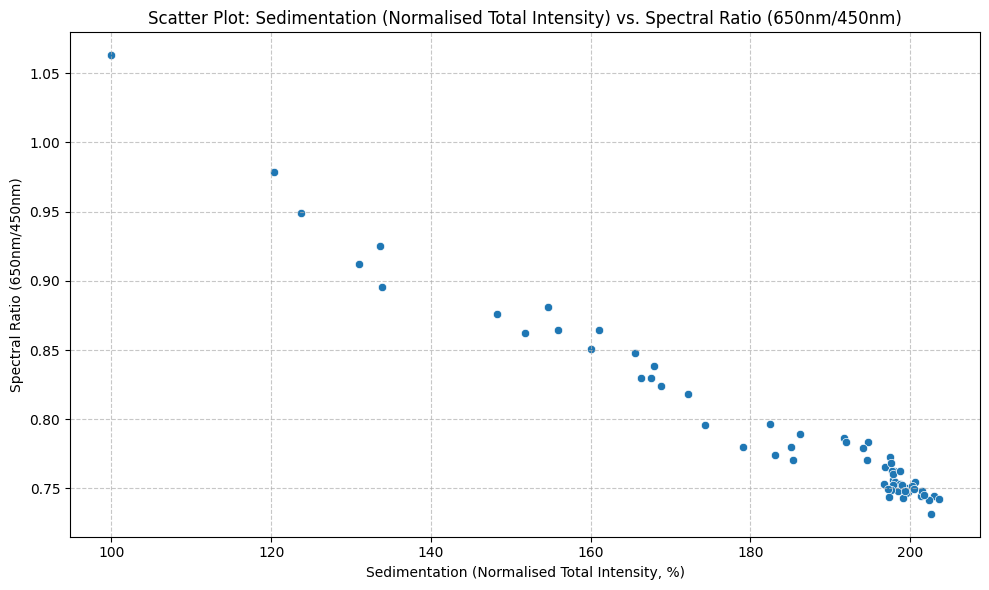

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=sedimentation_norm, y=spectral_ratio)
plt.title('Scatter Plot: Sedimentation (Normalised Total Intensity) vs. Spectral Ratio (650nm/450nm)')
plt.xlabel('Sedimentation (Normalised Total Intensity, %)')
plt.ylabel('Spectral Ratio (650nm/450nm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Dispersion Stability Analysis Summary

The dispersion stability analysis provides insights into how the sample's spectral properties change over time, indicating potential physical processes like sedimentation, agglomeration, or flocculation.

**Important Context:** The dispersion was shaken before logging, which might influence initial spectral readings due to temporary air bubbles or increased homogeneity. After the logging run, sedimentation of turmeric particles was observed at the bottom of the vial.

**Automated Dispersion Stability Report Breakdown:**

*   **Sedimentation Rate**: The report indicates a sedimentation rate of `2.280% change per minute`. The status "`Suspension is stable against heavy sedimentation.`" suggests that while there is some change, it's not severe enough to be classified as significant particle dropout based on the defined threshold (`-0.5%`). The first plot, **"1. Sedimentation Tracking (Total Scattering Mass)"**, visually represents this trend. A relatively flat line close to 100% (initial intensity) confirms stability against rapid settling.

*   **Agglomeration Slope**: The agglomeration slope is reported as `-0.00606 units/min`, triggering an alert: "`Spectral slope shifting, indicating possible particle growth/flocculation.`" This suggests that the ratio of intensities at 650nm to 450nm is changing, which can be an indicator of particles either growing in size or aggregating together. The second plot, **"2. Agglomeration / Flocculation Tracking (Spectral Slope)"**, illustrates this spectral ratio over time. A noticeable trend (either increasing or decreasing) in this plot supports the alert, implying changes in particle size distribution.

*   **Peak Shift Tracking**: The third plot, **"3. Peak Shift Tracking"**, shows how the wavelength of the maximum intensity changes over time. While the automated report didn't explicitly comment on this metric, this plot helps visualise any shifts in the characteristic absorption or scattering peak of the sample. Significant shifts could indicate chemical reactions or substantial changes in particle morphology/size.

### Correlation Analysis: Sedimentation vs. Spectral Ratio

**Pearson Correlation Coefficient**: The calculated Pearson Correlation between Sedimentation (Normalised Total Intensity) and Spectral Ratio (650nm/450nm) is **-0.9834**.

**Significance**: This indicates a **very strong negative correlation**. A correlation coefficient close to -1 suggests that as one variable increases, the other decreases proportionally. In this context:

*   As the **Normalised Total Intensity (Sedimentation)** *increases* (meaning less sedimentation or even an increase in apparent scattering due to other factors), the **Spectral Ratio (Agglomeration/Flocculation)** *decreases*.

This strong inverse relationship suggests that the processes influencing the overall scattering intensity are tightly coupled with those altering the spectral slope. For instance, if particles are settling, the total intensity might decrease, and if they are also agglomerating, the spectral ratio might change in a corresponding manner. The observed strong negative correlation implies that the spectral changes related to particle size (reflected in the spectral ratio) are consistently happening in tandem with changes in the total dispersed mass or scattering strength (reflected in the normalised total intensity).